In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict

In [6]:
def analyze_full_log(log_file_path: str):
    print(f"🔍 Analyzing log file: {log_file_path}")

    with open(log_file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        full_text = "".join(lines)

    exp_name_match = re.search(r'Starting Evaluation for Experiment: \[(.*?)\]', full_text)
    experiment_name = exp_name_match.group(1) if exp_name_match else "Unknown_Experiment"
    print(f"🔬 Detected Experiment: {experiment_name}")

    # ==========================================
    # 1. Node Scores 파싱 (정규표현식 활용)
    # ==========================================
    # 멀티라인으로 출력된 tensor([...]) 내부의 숫자들을 모두 추출합니다.
    score_matches = re.findall(r'node_scores:\s*tensor\(\[(.*?)\]\)', full_text, re.DOTALL)
    
    all_scores = []
    for match in score_matches:
        cleaned_str = match.replace('\n', ' ')
        # 쉼표로 분리 후 float 변환
        scores = [float(s.strip()) for s in cleaned_str.split(',') if s.strip()]
        all_scores.extend(scores)
        
    print(f"✅ Extracted {len(all_scores)} node scores across all queries.")

    # ==========================================
    # 2. 모듈별 실행 시간 파싱
    # ==========================================
    time_format = "%Y-%m-%d %H:%M:%S"
    durations = defaultdict(list)
    current_starts = {}

    # 로그에서 모듈의 시작과 끝을 알리는 키워드 정의
    markers = {
        "Graph Build": {"start": "Building Graph", "end": "Graph Build Completed."},
        "NLQ Encoding": {"start": "Encoding NLQ", "end": "Encoding NLQ Completed."},
        "Seed Selection": {"start": "Selecting Seed Nodes", "end": "Seed Nodes Selected"},
        "Subgraph Extraction": {"start": "Subgraph Extracting", "end": "Subgraph Extracted"},
        "Agent Filtering": {"start": "Agent Filtering", "end": "Agent Filtered"},
        "SQL Generation": {"start": "SQL Generation", "end": "Generated SQL:"}
    }

    ts_regex = re.compile(r'^\[(.*?)\]')

    for line in lines:
        ts_match = ts_regex.search(line)
        if not ts_match:
            continue
        
        ts_str = ts_match.group(1)
        try:
            ts = datetime.strptime(ts_str, time_format)
        except ValueError:
            continue
            
        # 상태 머신 방식으로 각 모듈의 소요 시간 계산
        for module, events in markers.items():
            if events["start"] in line:
                current_starts[module] = ts
            elif events["end"] in line and module in current_starts:
                duration = (ts - current_starts[module]).total_seconds()
                durations[module].append(duration)
                del current_starts[module] # 측정 완료 후 초기화

    # 평균 시간 계산
    avg_durations = {mod: np.mean(durs) if durs else 0.0 for mod, durs in durations.items()}
    
    for mod, avg_t in avg_durations.items():
        print(f"⏱️ Average time for [{mod}]: {avg_t:.3f} seconds (over {len(durations[mod])} queries)")

    # ==========================================
    # 3. 데이터 시각화 (Visualization)
    # ==========================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    fig.suptitle(f"Pipeline Analysis Report: {experiment_name}", fontsize=18, fontweight='bold', y=1.02)

    # [Plot 1] 전체 노드 스코어 분포 (Histogram)
    if all_scores:
        axes[0].hist(all_scores, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
        axes[0].axvline(np.mean(all_scores), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(all_scores):.3f}')
        axes[0].set_title('Global Distribution of Node Scores (1534 Queries)', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Cosine Similarity Score', fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)
        axes[0].legend()

    # [Plot 2] 모듈별 평균 실행 시간 (Bar Chart)
    if avg_durations:
        modules = list(avg_durations.keys())
        times = list(avg_durations.values())
        
        # 가독성을 위해 역순 정렬 (위에서 아래로 파이프라인 흐름)
        axes[1].barh(modules[::-1], times[::-1], color='coral', edgecolor='black')
        axes[1].set_title('Average Execution Time per Module', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Average Time (seconds)', fontsize=12)
        
        for i, v in enumerate(times[::-1]):
            axes[1].text(v + (max(times)*0.02), i, f"{v:.2f}s", va='center', fontweight='bold')

    plt.tight_layout()
    # save_path = f"pipeline_analysis_{experiments_name}.png"
    # plt.savefig(save_path, dpi=300)
    # print(f"📊 Visualization saved to: {save_path}")
    plt.show()

🔍 Analyzing log file: /home/hyeonjin/thesis_refactored/logs/baselines/preliminary_vector_only/eval/preliminary_vector_only_20260322_220127.log
🔬 Detected Experiment: preliminary_vector_only
✅ Extracted 14614 node scores across all queries.
⏱️ Average time for [Graph Build]: 0.023 seconds (over 177 queries)
⏱️ Average time for [Seed Selection]: 0.000 seconds (over 177 queries)
⏱️ Average time for [Subgraph Extraction]: 0.000 seconds (over 177 queries)
⏱️ Average time for [Agent Filtering]: 0.000 seconds (over 177 queries)
⏱️ Average time for [SQL Generation]: 1.028 seconds (over 176 queries)


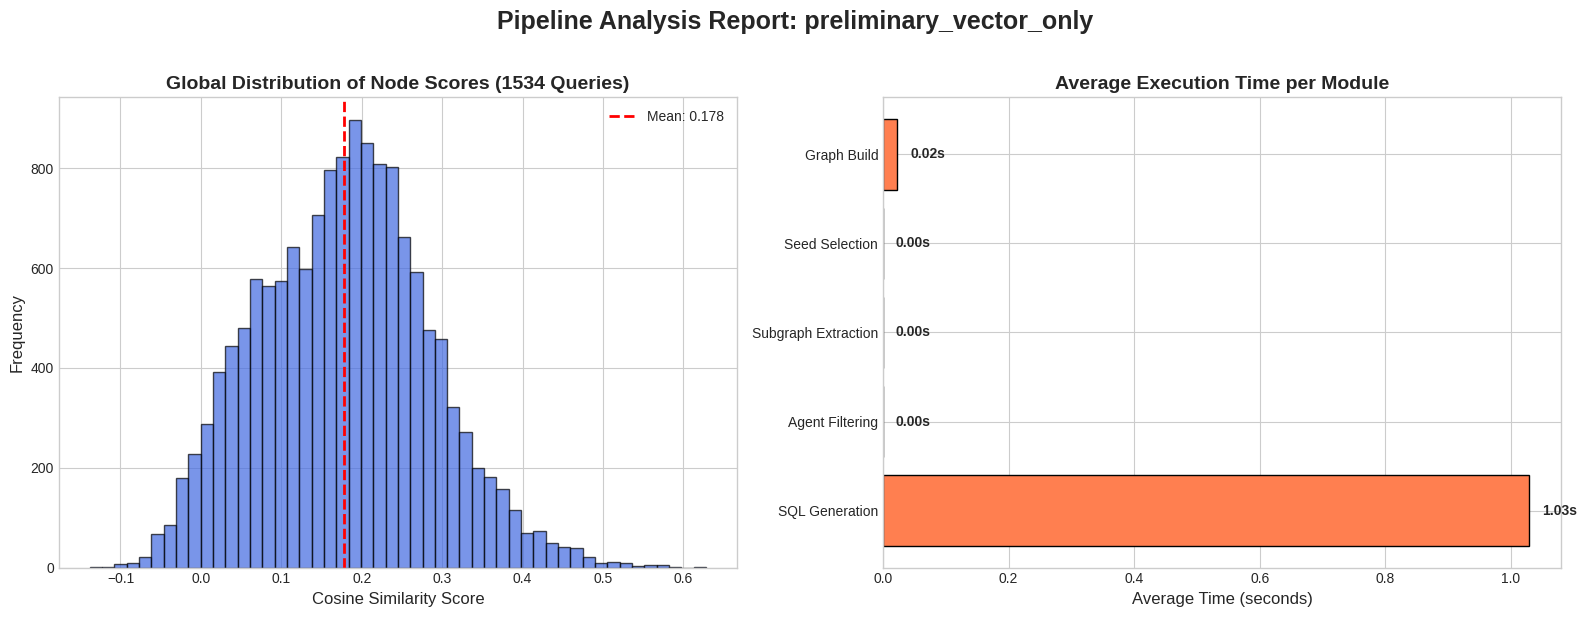

In [7]:
log_file_path = "/home/hyeonjin/thesis_refactored/logs/baselines/preliminary_vector_only/eval/preliminary_vector_only_20260322_220127.log"

analyze_full_log(log_file_path)

🔍 Analyzing log file: /home/hyeonjin/thesis_refactored/logs/baselines/preliminary_graph_expansion/eval/preliminary_graph_expansion_20260322_212637.log
🔬 Detected Experiment: preliminary_graph_expansion
✅ Extracted 20292 node scores across all queries.
⏱️ Average time for [Graph Build]: 0.023 seconds (over 352 queries)
⏱️ Average time for [Seed Selection]: 0.000 seconds (over 352 queries)
⏱️ Average time for [Subgraph Extraction]: 0.000 seconds (over 352 queries)
⏱️ Average time for [Agent Filtering]: 0.000 seconds (over 352 queries)
⏱️ Average time for [SQL Generation]: 3.185 seconds (over 352 queries)


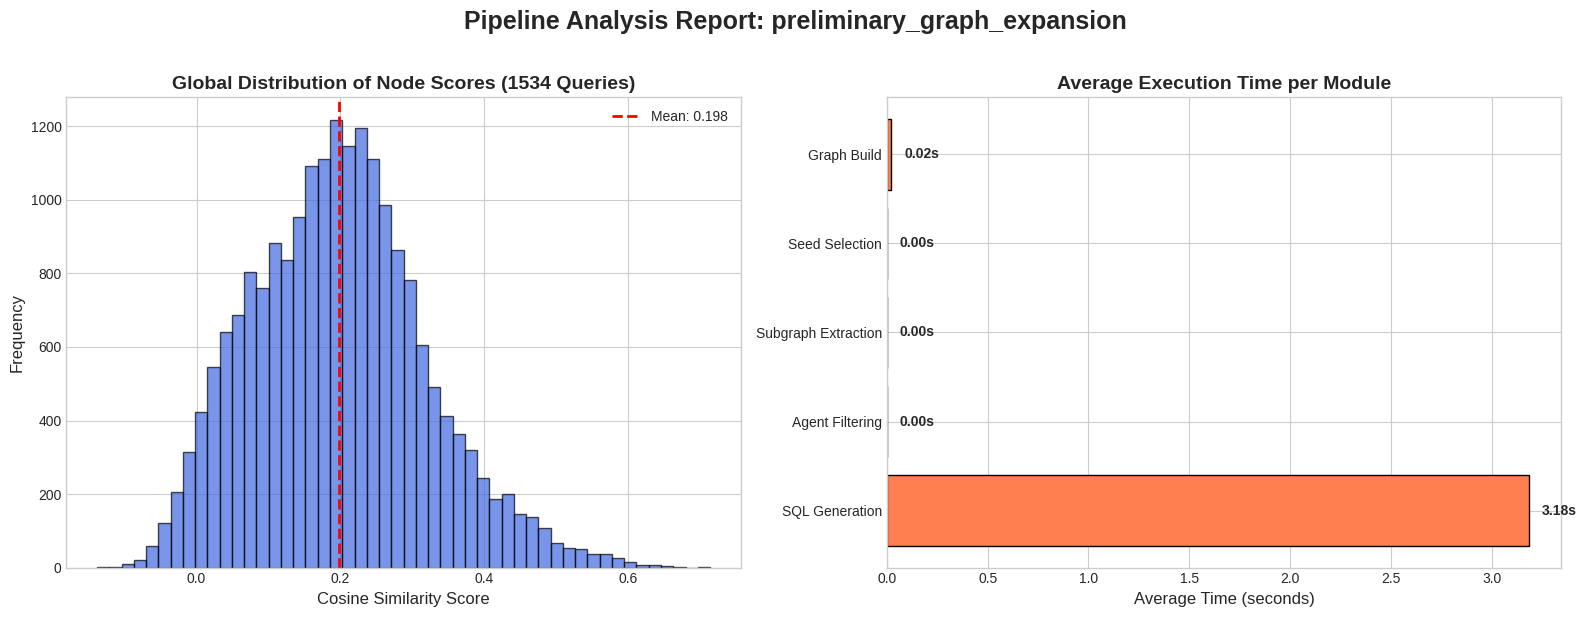

In [8]:
log_file_path = "/home/hyeonjin/thesis_refactored/logs/baselines/preliminary_graph_expansion/eval/preliminary_graph_expansion_20260322_212637.log"

analyze_full_log(log_file_path)

🔍 Analyzing log file: /home/hyeonjin/thesis_refactored/logs/baselines/preliminary_graph_and_agent/eval/preliminary_graph_and_agent_20260322_034951.log
🔬 Detected Experiment: preliminary_graph_and_agent
✅ Extracted 20292 node scores across all queries.
⏱️ Average time for [Graph Build]: 0.023 seconds (over 352 queries)
⏱️ Average time for [Seed Selection]: 0.000 seconds (over 352 queries)
⏱️ Average time for [Subgraph Extraction]: 0.000 seconds (over 352 queries)
⏱️ Average time for [Agent Filtering]: 8.381 seconds (over 352 queries)
⏱️ Average time for [SQL Generation]: 3.159 seconds (over 352 queries)


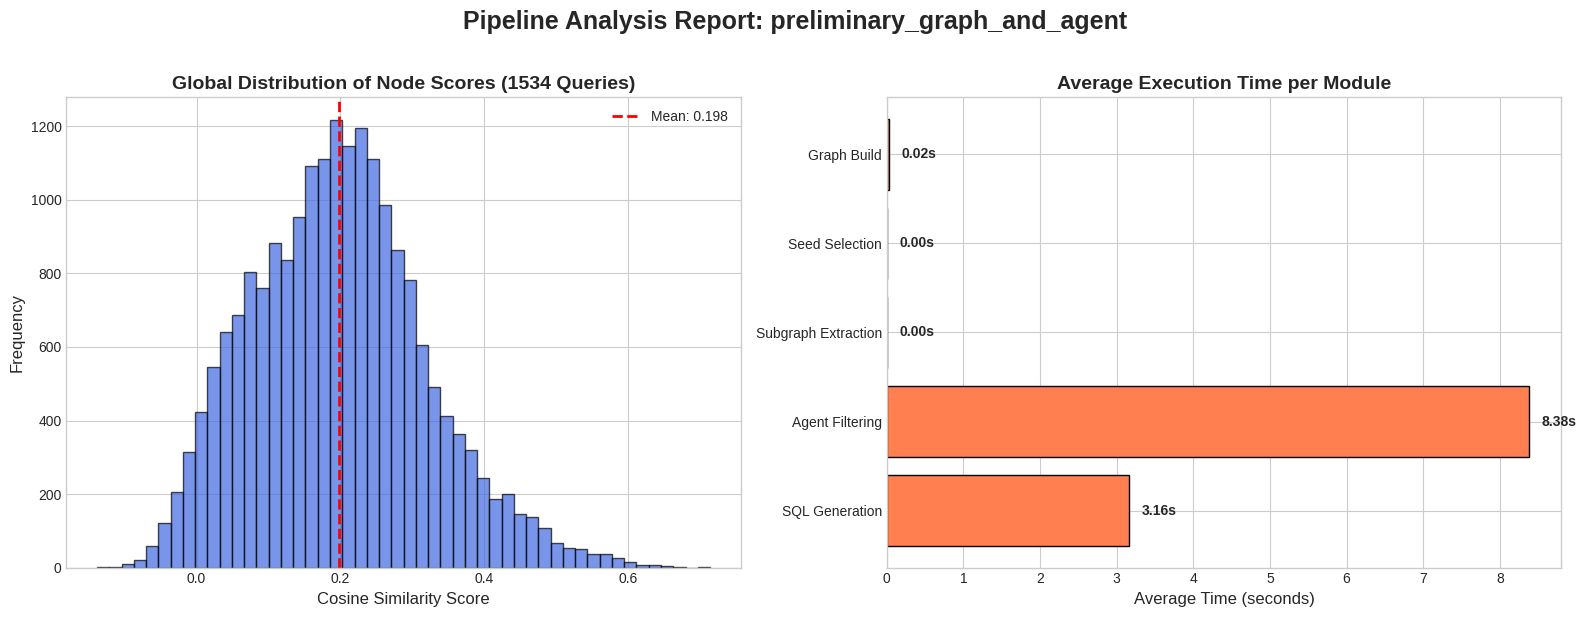

In [10]:
log_file_path = "/home/hyeonjin/thesis_refactored/logs/baselines/preliminary_graph_and_agent/eval/preliminary_graph_and_agent_20260322_034951.log"

analyze_full_log(log_file_path)

🔍 Analyzing log file: /home/hyeonjin/thesis_refactored/logs/baselines/baseline_xiyansql/eval/baseline_xiyansql_20260322_050925.log
🔬 Detected Experiment: baseline_xiyansql
✅ Extracted 142071 node scores across all queries.
⏱️ Average time for [Graph Build]: 0.046 seconds (over 1534 queries)


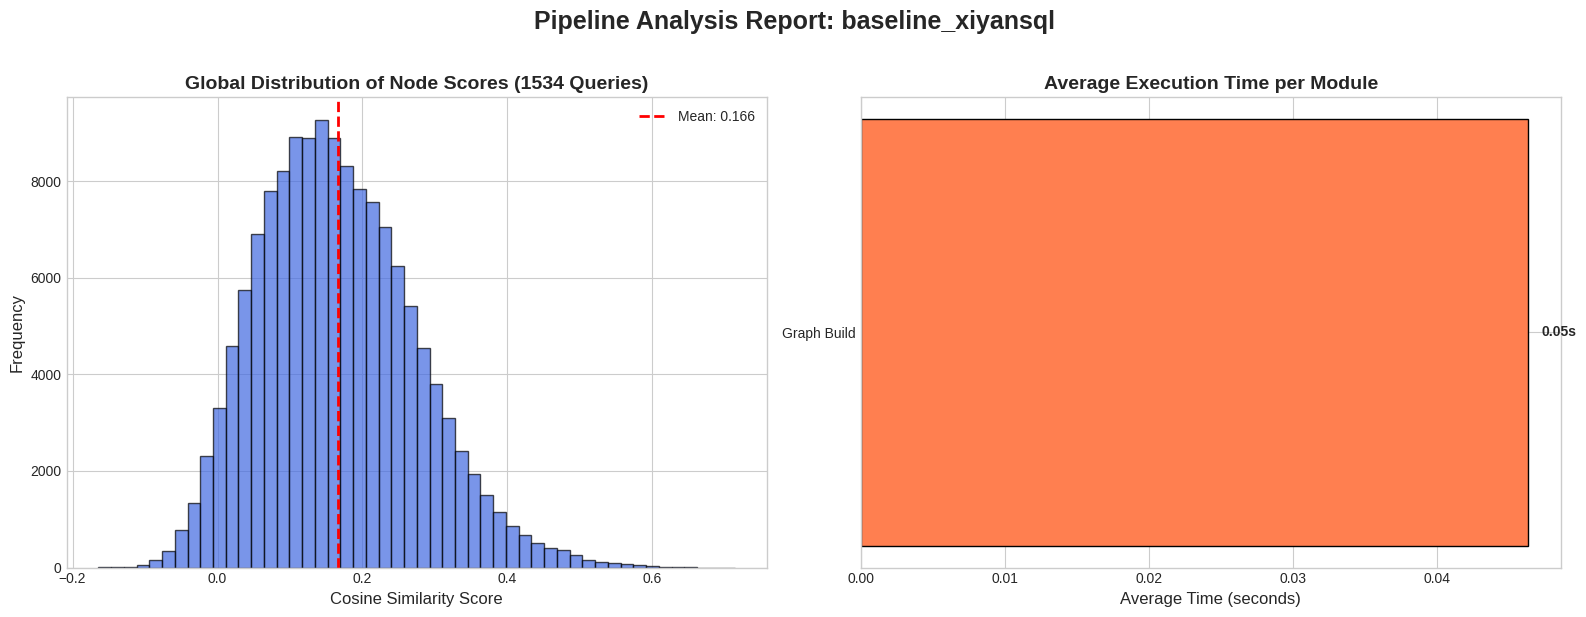

In [11]:
log_file_path = "/home/hyeonjin/thesis_refactored/logs/baselines/baseline_xiyansql/eval/baseline_xiyansql_20260322_050925.log"

analyze_full_log(log_file_path)